# Prediksi Penjualan Menggunakan Holt-Winters

## Metodologi

1. Memuat data hasil agregasi dari PostgreSQL.
2. Membangun model Holt-Winters untuk prediksi penjualan.
3. Memvisualisasikan data.

## Persiapan Data dan Library

Mengimpor library yang dibutuhkan dan memuat dataset untuk proses analisis.

In [1]:
# Mengimpor library
import pandas as pd
import numpy as np
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings(action='ignore', category=RuntimeWarning)
warnings.filterwarnings(action='ignore', category=FutureWarning)

# Memuat data
df = pd.read_csv('Data/superstore_monthly_sales.csv')
df['order_date'] = pd.to_datetime(df['order_date'], yearfirst=True, errors='coerce')

## Bangun Model Holt-Winters

Membangun model Holt-Winters untuk memprediksi penjualan 6 bulan ke depan.

In [2]:
# Parameter hasil tuning
params = {
    'smoothing_level': 1.4901161246499267e-08,
    'smoothing_trend': 1.4894067603478807e-08,
    'smoothing_seasonal': 0.0,
    'initial_level': 0.019769140440638724,
    'initial_trend': 1.061574335146248,
    'initial_seasons': np.array([
        0.15409131, 0.06109829, 0.41872238, 0.24284277,
        0.28091854, 0.26974947, 0.2490747, 0.27105927,
        0.63429356, 0.35845589, 0.7301054 , 0.65166315
    ])
}

# Scaling data untuk meringankan beban komputasi
endog = df['sales'].values / 100_000

# Bangun model forecasting menggunakan holt-winters
model = ExponentialSmoothing(endog=endog, trend='mul', seasonal='add', seasonal_periods=12,
                             initialization_method='known',
                             initial_level=params['initial_level'],
                             initial_trend=params['initial_trend'],
                             initial_seasonal=params['initial_seasons'])

fit_model = model.fit(smoothing_level=params['smoothing_level'],
                      smoothing_trend=params['smoothing_trend'],
                      smoothing_seasonal=params['smoothing_seasonal'],
                      optimized=False)

# Forecast 6 bulan kedepan
forecast = fit_model.forecast(steps=6) * 100_000

## Visualisasi Hasil Forecasting

Memvisualisasikan hasil forecast bersama data aktual tahun 2017 untuk melihat kelanjutan pola penjualan.

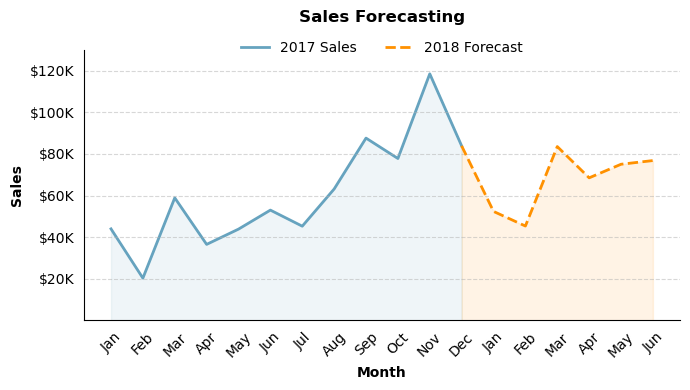

In [3]:
df_2017 = df[df['order_year'] == 2017].copy()
sales = df_2017['sales'].values
sales_forecast = np.array([df['sales'].values[-1]] + forecast.tolist())

plt.figure(figsize=(7,4))
sns.lineplot(x=np.array(range(len(sales))), y=sales, ls='-', lw=2, color='#66A3BF', zorder=1, label='2017 Sales')
plt.fill_between(x=np.array(range(len(sales))), y1=sales, color='#66A3BF', alpha=0.1)
sns.lineplot(x=np.array(range(11, 18)), y=sales_forecast, ls='--', lw=2, color='#FF9100', zorder=2, label='2018 Forecast')
plt.fill_between(x=np.array(range(11, 18)), y1=sales_forecast, color='#FF9100', alpha=0.1)

title_dict = {'family':plt.rcParams['font.family'],
              'size':12,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'pad':20,
              'alpha':1}

label_dict = {'x':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':0,
              'alpha':1}, 
              
              'y':
              {'family':plt.rcParams['font.family'],
              'size':10,
              'weight':'bold',
              'color':'black',
              'loc':'center',
              'rotation':90,
              'alpha':1}}

plt.title('Sales Forecasting', **title_dict)
plt.xlabel('Month', **label_dict['x'])
plt.ylabel('Sales', **label_dict['y'])

ax = plt.gca()
ax.tick_params(which='major', axis='both', left=False, bottom=False)
months = df_2017['order_month'].map(lambda x: x[:3]).values.tolist()
months += months[:6]
ax.set_xticks(ticks=list(range(18)), labels=months, rotation=45)
ax.set_yticks(ticks=ax.get_yticks()[2:-1])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${y/1_000:.0f}K'))
ax.set_ylim(0, 130_000)

plt.legend(loc='upper center', frameon=False, bbox_to_anchor=(0.5, 1.08), ncol=2, prop={'size':10, 'weight':'normal'})
plt.grid(which='major', axis='y', ls='--', alpha=0.5)
plt.tight_layout()
sns.despine(left=False, top=True, right=True, bottom=False)
plt.show()

## Menyiapkan Data Forecast

Menambahkan hasil forecast ke data aktual.

In [4]:
data = {'order_date':[f'2018-{str(i).zfill(2)}-01' for i in range(1,7)],
        'sales':forecast,
        'data_type':['Forecast' for _ in range(6)]}

df_forecast = pd.DataFrame(data)
df_forecast['order_date'] = pd.to_datetime(df_forecast['order_date'], yearfirst=True, errors='coerce')
df_forecast['order_year'] = df_forecast['order_date'].dt.year
df_forecast['order_month'] = df_forecast['order_date'].dt.strftime('%B')
df_forecast['month_number'] = df_forecast['order_date'].dt.month
df_forecast['profit'] = np.NaN
df_forecast = df_forecast.reindex(columns=df.columns)
df_final = pd.concat([df, df_forecast], axis=0, ignore_index=True)

df_final.to_excel('superstore_sales_forecast.xlsx', index=False)